# Notebook 02: Exploratory Data Analysis

**Objective:** Explore the cleaned dataset to uncover churn patterns,
revenue risk, and customer behaviour insights that will drive the
Power BI dashboard design and business recommendations.

## Analysis Plan
1. Overall churn rate
2. Revenue at risk
3. Churn by contract type
4. Churn by tenure band
5. Churn by payment method
6. Churn by internet service
7. Churn by senior citizen
8. Churn by service count

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

# Load cleaned dataset
df = pd.read_csv('C:/Users/Lenevo/telecom-churn-analytics/telecom-churn-analytics/data/processed/telco_churn_clean.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")


Dataset loaded successfully!
Shape: (7032, 37)


## 1. Overall Churn Rate

Churn Distribution:
Churn Label
No     5163
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn Label
No     73.42
Yes    26.58
Name: proportion, dtype: float64


C:\Users\Lenevo\AppData\Local\Temp\ipykernel_18572\522821501.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_counts.index, y=churn_counts.values,


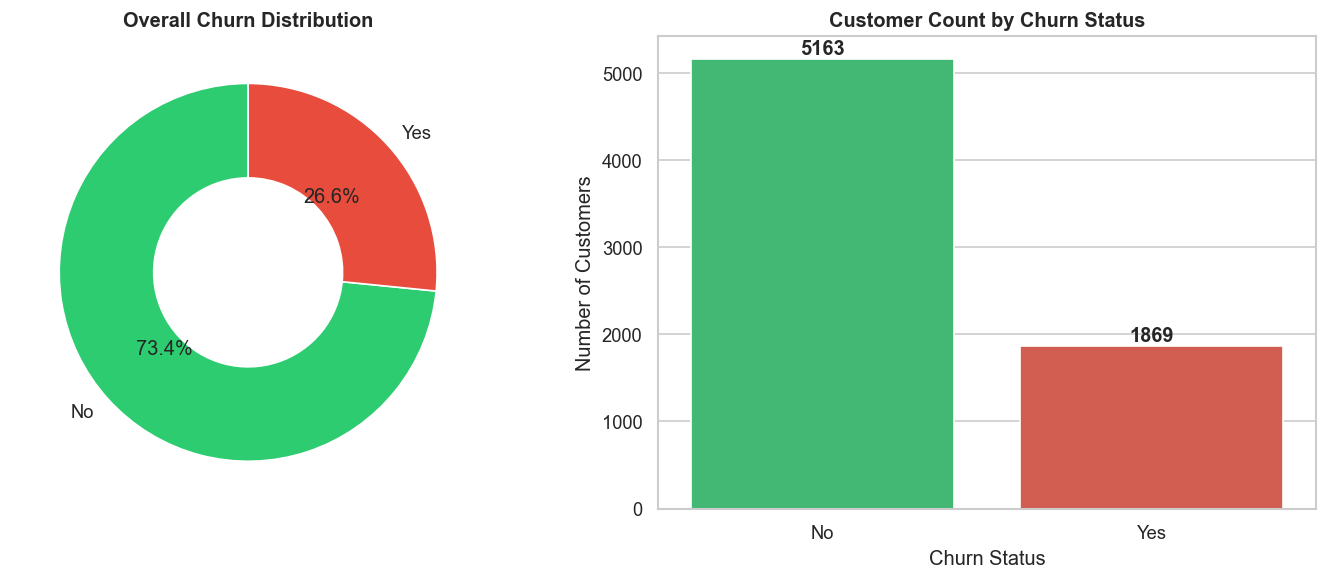

Chart saved to visuals/


In [2]:
# Overall churn distribution
churn_counts = df['Churn Label'].value_counts()
churn_pct = df['Churn Label'].value_counts(normalize=True).mul(100).round(2)

print("Churn Distribution:")
print(churn_counts)
print("\nChurn Percentage:")
print(churn_pct)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Donut chart
axes[0].pie(churn_counts, labels=churn_counts.index,
            autopct='%1.1f%%', startangle=90,
            colors=['#2ecc71', '#e74c3c'],
            wedgeprops=dict(width=0.5))
axes[0].set_title('Overall Churn Distribution', fontweight='bold')

# Bar chart
sns.barplot(x=churn_counts.index, y=churn_counts.values,
            palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title('Customer Count by Churn Status', fontweight='bold')
axes[1].set_xlabel('Churn Status')
axes[1].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../visuals/01_churn_distribution.png', bbox_inches='tight')
plt.show()
print("Chart saved to visuals/")

## 2. Revenue at Risk
How much monthly revenue are we losing to churned customers?

REVENUE SUMMARY
Total Monthly Revenue:     $455,661.00
Retained Customer Revenue: $316,530.15
Revenue Lost to Churn:     $139,130.85
Percentage at Risk:        30.53%


C:\Users\Lenevo\AppData\Local\Temp\ipykernel_18572\1549315958.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_charges.index, y=avg_charges.values,


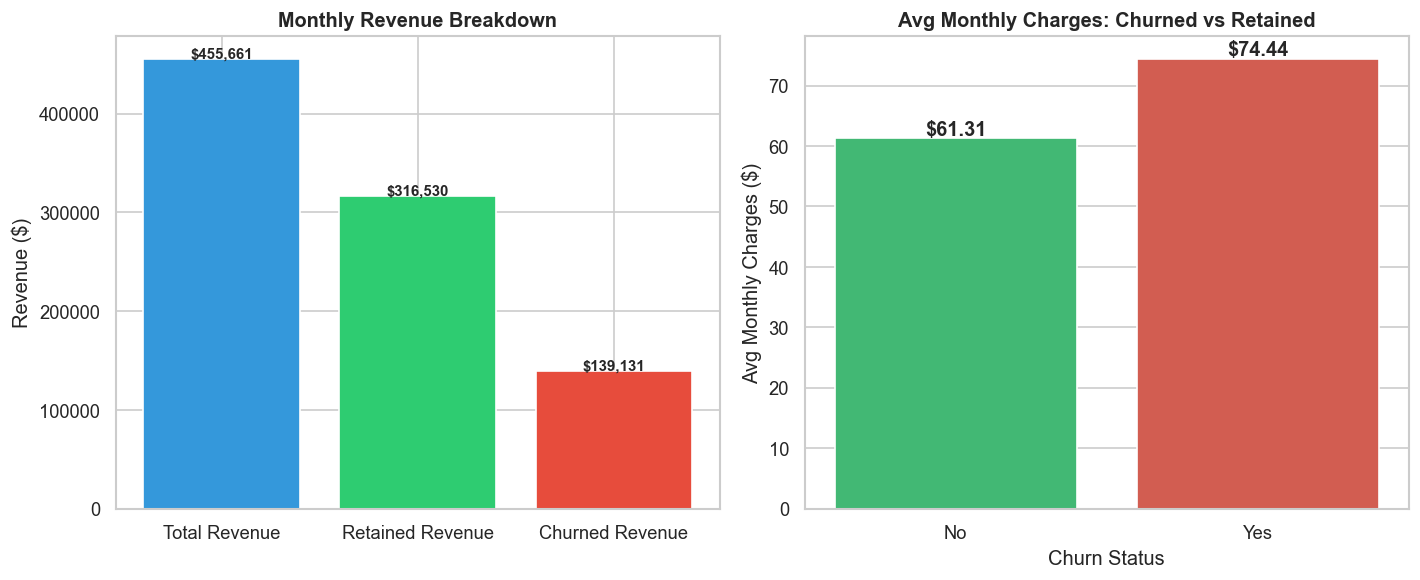

Chart saved to visuals/


In [4]:
# Revenue analysis
total_revenue = df['Monthly Charges'].sum().round(2)
churned_revenue = df[df['Churn Label'] == 'Yes']['Monthly Charges'].sum().round(2)
retained_revenue = df[df['Churn Label'] == 'No']['Monthly Charges'].sum().round(2)
pct_at_risk = round((churned_revenue / total_revenue) * 100, 2)

print("=" * 45)
print("REVENUE SUMMARY")
print("=" * 45)
print(f"Total Monthly Revenue:     ${total_revenue:,.2f}")
print(f"Retained Customer Revenue: ${retained_revenue:,.2f}")
print(f"Revenue Lost to Churn:     ${churned_revenue:,.2f}")
print(f"Percentage at Risk:        {pct_at_risk}%")
print("=" * 45)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Revenue comparison bar
categories = ['Total Revenue', 'Retained Revenue', 'Churned Revenue']
values = [total_revenue, retained_revenue, churned_revenue]
colors = ['#3498db', '#2ecc71', '#e74c3c']
bars = axes[0].bar(categories, values, color=colors, edgecolor='white')
axes[0].set_title('Monthly Revenue Breakdown', fontweight='bold')
axes[0].set_ylabel('Revenue ($)')
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1000,
                 f'${val:,.0f}', ha='center', fontweight='bold', fontsize=9)

# Avg monthly charges — churned vs retained
avg_charges = df.groupby('Churn Label')['Monthly Charges'].mean().round(2)
sns.barplot(x=avg_charges.index, y=avg_charges.values,
            palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title('Avg Monthly Charges: Churned vs Retained', fontweight='bold')
axes[1].set_xlabel('Churn Status')
axes[1].set_ylabel('Avg Monthly Charges ($)')
for i, v in enumerate(avg_charges.values):
    axes[1].text(i, v + 0.5, f'${v}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../visuals/02_revenue_analysis.png', bbox_inches='tight')
plt.show()
print("Chart saved to visuals/")


## 3. Churn by Contract Type
Contract type is the strongest predictor of churn.
Month-to-month customers have significantly higher churn rates.

Churn Rate by Contract Type:
                Churn Rate  Total Customers  Churned  Churn Rate %
Contract                                                          
Month-to-month       0.427             3875     1655          42.7
One year             0.113             1472      166          11.3
Two year             0.028             1685       48           2.8


C:\Users\Lenevo\AppData\Local\Temp\ipykernel_18572\2560293603.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=contract_churn.index, y=contract_churn['Churn Rate %'],


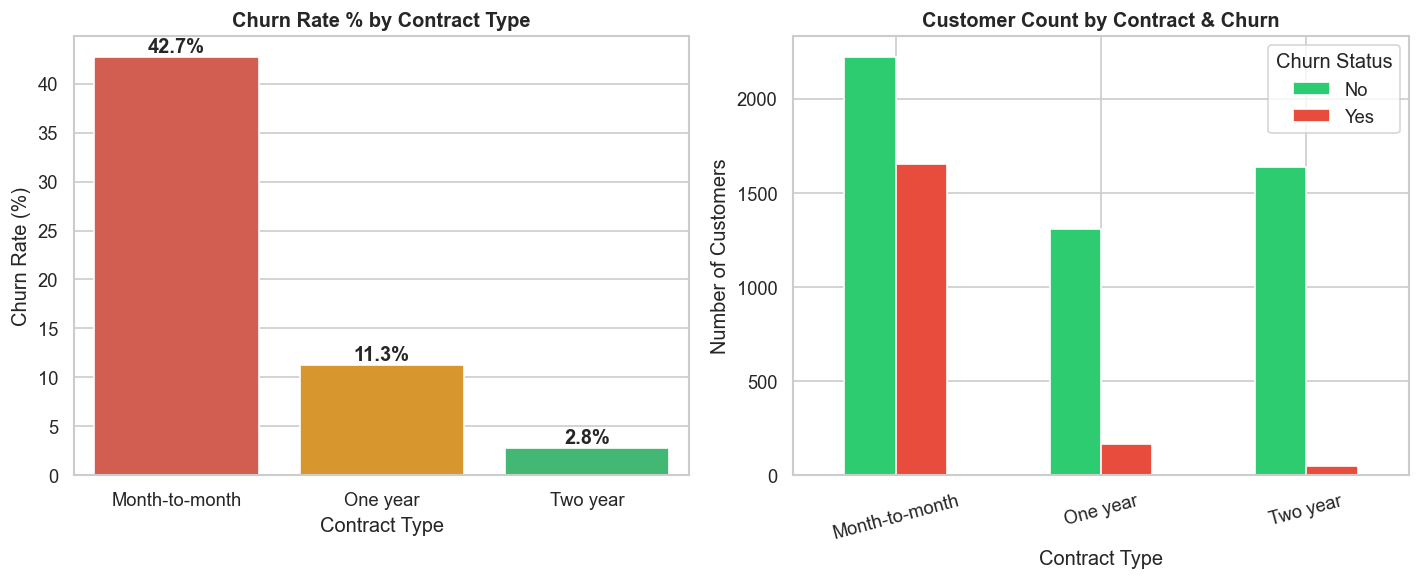

Chart saved to visuals/


In [5]:
# Churn rate by contract type
contract_churn = df.groupby('Contract')['Churn Value'].agg(['mean', 'count', 'sum']).round(3)
contract_churn.columns = ['Churn Rate', 'Total Customers', 'Churned']
contract_churn['Churn Rate %'] = (contract_churn['Churn Rate'] * 100).round(2)
contract_churn = contract_churn.sort_values('Churn Rate %', ascending=False)

print("Churn Rate by Contract Type:")
print(contract_churn)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Churn rate % by contract
sns.barplot(x=contract_churn.index, y=contract_churn['Churn Rate %'],
            palette=['#e74c3c', '#f39c12', '#2ecc71'], ax=axes[0])
axes[0].set_title('Churn Rate % by Contract Type', fontweight='bold')
axes[0].set_xlabel('Contract Type')
axes[0].set_ylabel('Churn Rate (%)')
for i, v in enumerate(contract_churn['Churn Rate %'].values):
    axes[0].text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')

# Customer count by contract — stacked
contract_status = df.groupby(['Contract', 'Churn Label']).size().unstack()
contract_status.plot(kind='bar', ax=axes[1], 
                     color=['#2ecc71', '#e74c3c'],
                     edgecolor='white')
axes[1].set_title('Customer Count by Contract & Churn', fontweight='bold')
axes[1].set_xlabel('Contract Type')
axes[1].set_ylabel('Number of Customers')
axes[1].legend(title='Churn Status')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../visuals/03_churn_by_contract.png', bbox_inches='tight')
plt.show()
print("Chart saved to visuals/")

## 4. Churn by Tenure Band
How does customer loyalty duration affect churn probability?
Early tenure customers are the highest risk group.

Churn Rate by Tenure Band:
              Churn Rate  Total Customers  Churned  Churn Rate %
Tenure Band                                                     
0-12 Months        0.477             2175     1037          47.7
13-24 Months       0.287             1024      294          28.7
25-48 Months       0.204             1594      325          20.4
49-60 Months       0.144              832      120          14.4
61+ Months         0.066             1407       93           6.6


C:\Users\Lenevo\AppData\Local\Temp\ipykernel_18572\3348609504.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tenure_churn.index, y=tenure_churn['Churn Rate %'],
C:\Users\Lenevo\AppData\Local\Temp\ipykernel_18572\3348609504.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tenure_churn.index, y=tenure_churn['Total Customers'],


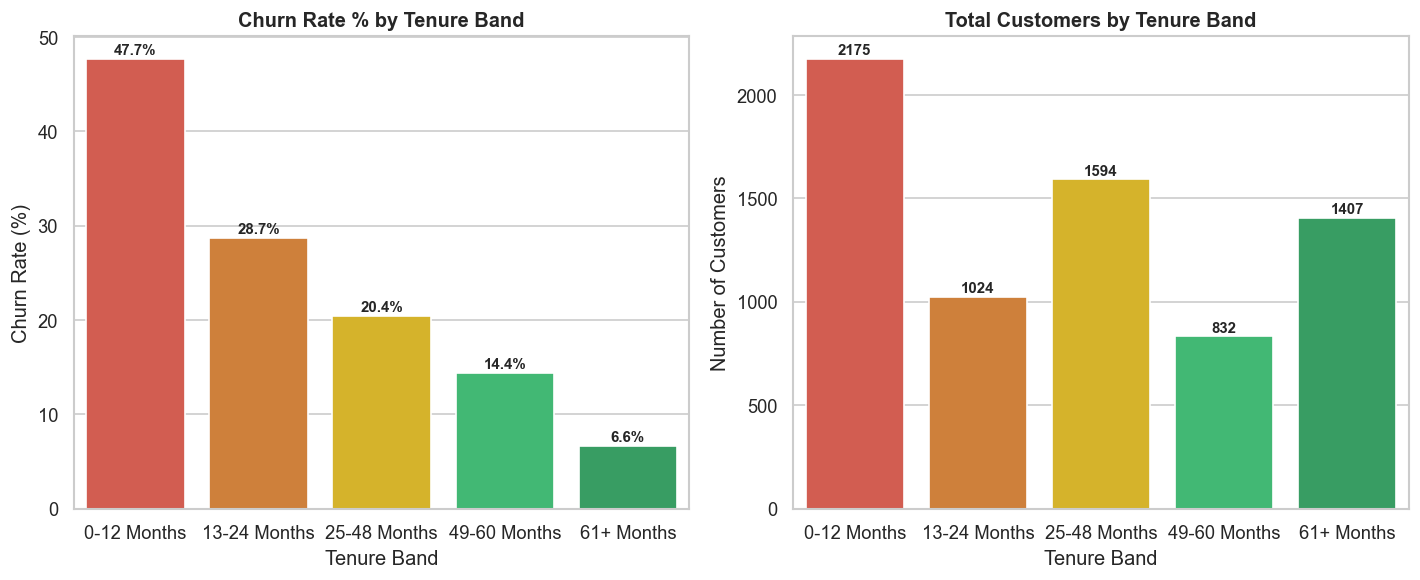

Chart saved to visuals/


In [6]:
# Churn rate by tenure band
tenure_churn = df.groupby('Tenure Band')['Churn Value'].agg(['mean', 'count', 'sum']).round(3)
tenure_churn.columns = ['Churn Rate', 'Total Customers', 'Churned']
tenure_churn['Churn Rate %'] = (tenure_churn['Churn Rate'] * 100).round(2)

print("Churn Rate by Tenure Band:")
print(tenure_churn)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Churn rate by tenure band
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
sns.barplot(x=tenure_churn.index, y=tenure_churn['Churn Rate %'],
            palette=colors, ax=axes[0])
axes[0].set_title('Churn Rate % by Tenure Band', fontweight='bold')
axes[0].set_xlabel('Tenure Band')
axes[0].set_ylabel('Churn Rate (%)')
for i, v in enumerate(tenure_churn['Churn Rate %'].values):
    axes[0].text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold', fontsize=9)

# Customer count by tenure band
sns.barplot(x=tenure_churn.index, y=tenure_churn['Total Customers'],
            palette=colors, ax=axes[1])
axes[1].set_title('Total Customers by Tenure Band', fontweight='bold')
axes[1].set_xlabel('Tenure Band')
axes[1].set_ylabel('Number of Customers')
for i, v in enumerate(tenure_churn['Total Customers'].values):
    axes[1].text(i, v + 20, str(v), ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('../visuals/04_churn_by_tenure.png', bbox_inches='tight')
plt.show()
print("Chart saved to visuals/")

## 5. Churn by Payment Method
Payment method reveals both customer engagement levels
and potential friction points in the billing experience.

Churn Rate by Payment Method:
                           Churn Rate  Total Customers  Churned  Churn Rate %
Payment Method                                                               
Electronic check                0.453             2365     1071          45.3
Mailed check                    0.192             1604      308          19.2
Bank transfer (automatic)       0.167             1542      258          16.7
Credit card (automatic)         0.153             1521      232          15.3


C:\Users\Lenevo\AppData\Local\Temp\ipykernel_18572\331801015.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=payment_churn.index, x=payment_churn['Churn Rate %'],
C:\Users\Lenevo\AppData\Local\Temp\ipykernel_18572\331801015.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=payment_revenue.index, x=payment_revenue.values,


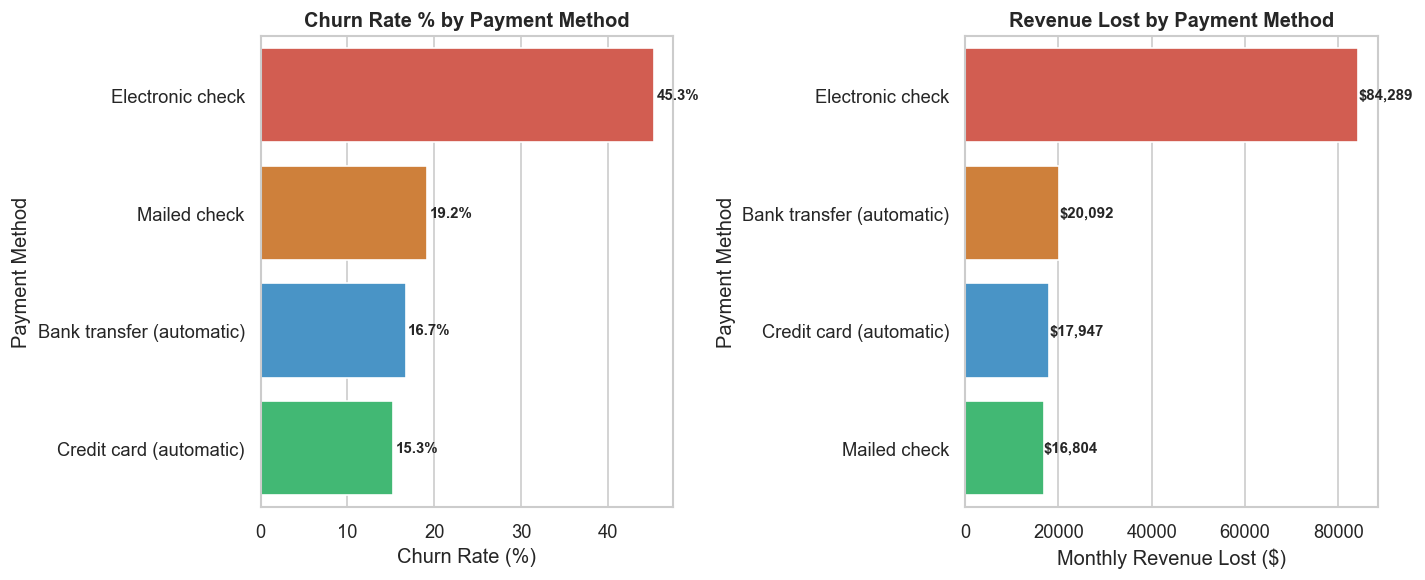

Chart saved to visuals/


In [7]:
# Churn rate by payment method
payment_churn = df.groupby('Payment Method')['Churn Value'].agg(['mean', 'count', 'sum']).round(3)
payment_churn.columns = ['Churn Rate', 'Total Customers', 'Churned']
payment_churn['Churn Rate %'] = (payment_churn['Churn Rate'] * 100).round(2)
payment_churn = payment_churn.sort_values('Churn Rate %', ascending=False)

print("Churn Rate by Payment Method:")
print(payment_churn)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Churn rate % horizontal bar
colors = ['#e74c3c', '#e67e22', '#3498db', '#2ecc71']
sns.barplot(y=payment_churn.index, x=payment_churn['Churn Rate %'],
            palette=colors, ax=axes[0])
axes[0].set_title('Churn Rate % by Payment Method', fontweight='bold')
axes[0].set_xlabel('Churn Rate (%)')
axes[0].set_ylabel('Payment Method')
for i, v in enumerate(payment_churn['Churn Rate %'].values):
    axes[0].text(v + 0.3, i, f'{v}%', va='center', fontweight='bold', fontsize=9)

# Revenue at risk by payment method
payment_revenue = df[df['Churn Label'] == 'Yes'].groupby(
    'Payment Method')['Monthly Charges'].sum().round(2)
payment_revenue = payment_revenue.sort_values(ascending=False)
sns.barplot(y=payment_revenue.index, x=payment_revenue.values,
            palette=colors, ax=axes[1])
axes[1].set_title('Revenue Lost by Payment Method', fontweight='bold')
axes[1].set_xlabel('Monthly Revenue Lost ($)')
axes[1].set_ylabel('Payment Method')
for i, v in enumerate(payment_revenue.values):
    axes[1].text(v + 100, i, f'${v:,.0f}', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('../visuals/05_churn_by_payment.png', bbox_inches='tight')
plt.show()
print("Chart saved to visuals/")

## 6. Churn by Internet Service
Fiber optic customers show significantly higher churn rates
despite paying premium prices — a critical product insight.

Churn Rate by Internet Service:
                  Churn Rate  Total Customers  Churned  Churn Rate %
Internet Service                                                    
Fiber optic            0.419             3096     1297          41.9
DSL                    0.190             2416      459          19.0
No                     0.074             1520      113           7.4


C:\Users\Lenevo\AppData\Local\Temp\ipykernel_18572\386319750.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=internet_churn.index, y=internet_churn['Churn Rate %'],


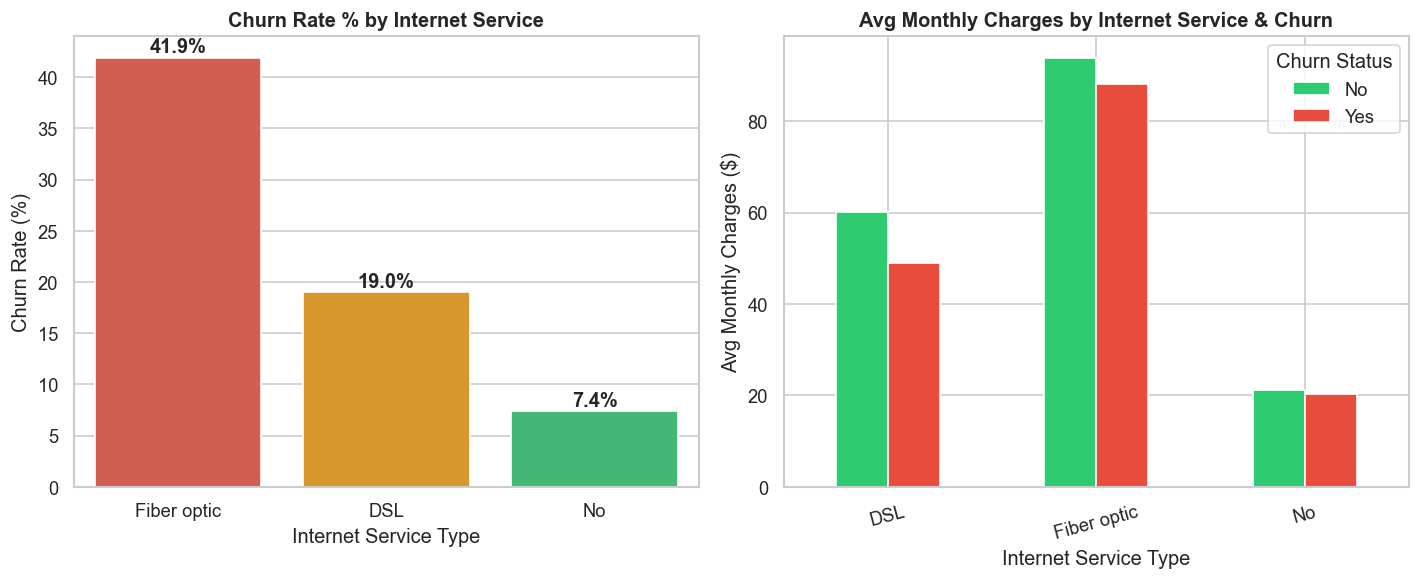

Chart saved to visuals/


In [8]:
# Churn rate by internet service
internet_churn = df.groupby('Internet Service')['Churn Value'].agg(['mean', 'count', 'sum']).round(3)
internet_churn.columns = ['Churn Rate', 'Total Customers', 'Churned']
internet_churn['Churn Rate %'] = (internet_churn['Churn Rate'] * 100).round(2)
internet_churn = internet_churn.sort_values('Churn Rate %', ascending=False)

print("Churn Rate by Internet Service:")
print(internet_churn)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Churn rate by internet service
colors = ['#e74c3c', '#f39c12', '#2ecc71']
sns.barplot(x=internet_churn.index, y=internet_churn['Churn Rate %'],
            palette=colors, ax=axes[0])
axes[0].set_title('Churn Rate % by Internet Service', fontweight='bold')
axes[0].set_xlabel('Internet Service Type')
axes[0].set_ylabel('Churn Rate (%)')
for i, v in enumerate(internet_churn['Churn Rate %'].values):
    axes[0].text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')

# Avg monthly charges by internet service and churn
avg_charges = df.groupby(['Internet Service', 'Churn Label'])['Monthly Charges'].mean().round(2).unstack()
avg_charges.plot(kind='bar', ax=axes[1],
                 color=['#2ecc71', '#e74c3c'],
                 edgecolor='white')
axes[1].set_title('Avg Monthly Charges by Internet Service & Churn', fontweight='bold')
axes[1].set_xlabel('Internet Service Type')
axes[1].set_ylabel('Avg Monthly Charges ($)')
axes[1].legend(title='Churn Status')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../visuals/06_churn_by_internet.png', bbox_inches='tight')
plt.show()
print("Chart saved to visuals/")


## 7. Churn by Senior Citizen Status
Senior citizens represent a vulnerable and potentially
underserved customer segment with higher churn risk.

Churn Rate by Senior Citizen Status:
                Churn Rate  Total Customers  Churned  Churn Rate %
Senior Citizen                                                    
No                   0.237             5890     1393          23.7
Yes                  0.417             1142      476          41.7


C:\Users\Lenevo\AppData\Local\Temp\ipykernel_18572\244644397.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=senior_churn.index, y=senior_churn['Churn Rate %'],


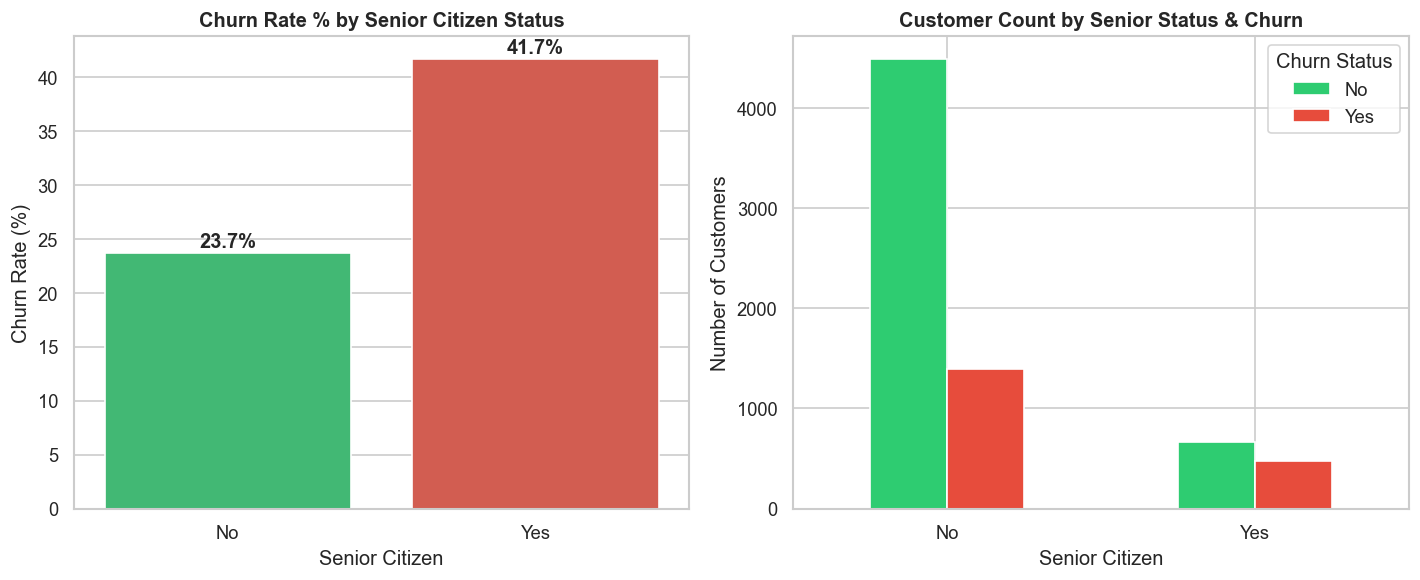

Chart saved to visuals/


In [9]:
# Churn rate by senior citizen status
senior_churn = df.groupby('Senior Citizen')['Churn Value'].agg(['mean', 'count', 'sum']).round(3)
senior_churn.columns = ['Churn Rate', 'Total Customers', 'Churned']
senior_churn['Churn Rate %'] = (senior_churn['Churn Rate'] * 100).round(2)

print("Churn Rate by Senior Citizen Status:")
print(senior_churn)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Churn rate
sns.barplot(x=senior_churn.index, y=senior_churn['Churn Rate %'],
            palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Churn Rate % by Senior Citizen Status', fontweight='bold')
axes[0].set_xlabel('Senior Citizen')
axes[0].set_ylabel('Churn Rate (%)')
for i, v in enumerate(senior_churn['Churn Rate %'].values):
    axes[0].text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')

# Customer distribution
senior_dist = df.groupby(['Senior Citizen', 'Churn Label']).size().unstack()
senior_dist.plot(kind='bar', ax=axes[1],
                 color=['#2ecc71', '#e74c3c'],
                 edgecolor='white')
axes[1].set_title('Customer Count by Senior Status & Churn', fontweight='bold')
axes[1].set_xlabel('Senior Citizen')
axes[1].set_ylabel('Number of Customers')
axes[1].legend(title='Churn Status')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../visuals/07_churn_by_senior.png', bbox_inches='tight')
plt.show()
print("Chart saved to visuals/")


## 8. Churn by Service Count
Customers with more add-on services are stickier.
Bundling is the cheapest retention tool available.

Churn Rate by Service Count:
               Churn Rate  Total Customers  Churned  Churn Rate %
Service Count                                                    
0                   0.438               80       35          43.8
1                   0.217             2247      488          21.7
2                   0.435              996      433          43.5
3                   0.347             1041      361          34.7
4                   0.273             1060      289          27.3
5                   0.221              825      182          22.1
6                   0.126              524       66          12.6
7                   0.058              259       15           5.8


C:\Users\Lenevo\AppData\Local\Temp\ipykernel_18572\2379370031.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=service_churn.index, y=service_churn['Churn Rate %'],
C:\Users\Lenevo\AppData\Local\Temp\ipykernel_18572\2379370031.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=service_churn.index, y=service_churn['Total Customers'],


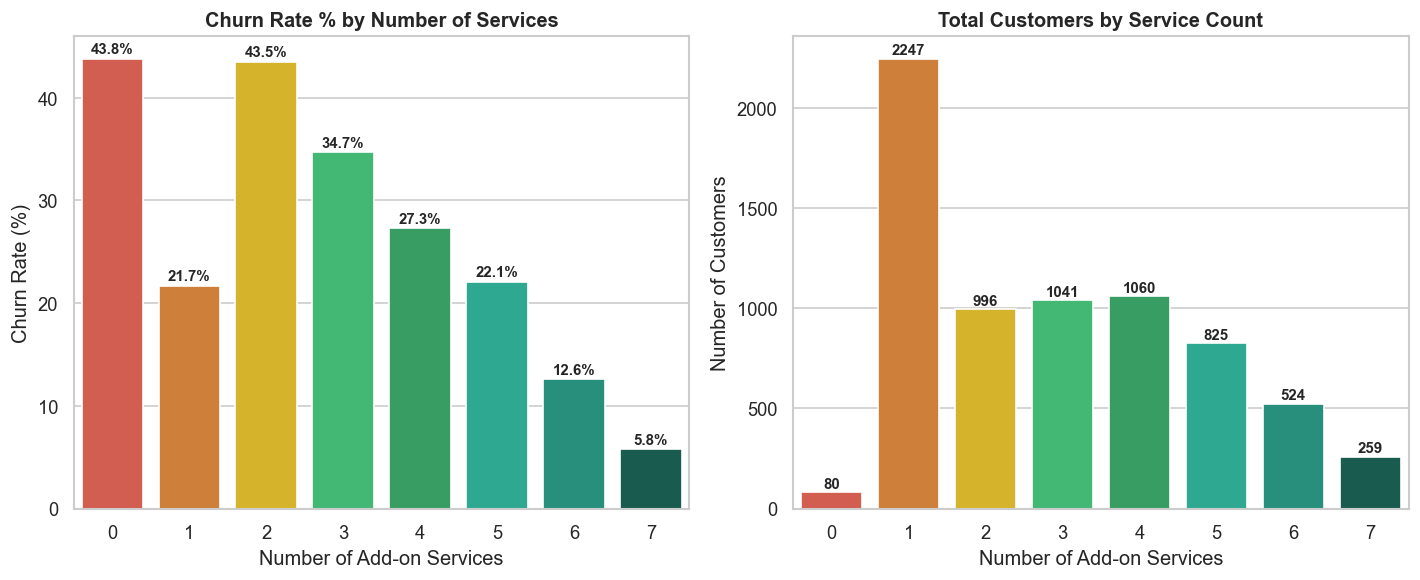

Chart saved to visuals/


In [10]:
# Churn rate by service count
service_churn = df.groupby('Service Count')['Churn Value'].agg(['mean', 'count', 'sum']).round(3)
service_churn.columns = ['Churn Rate', 'Total Customers', 'Churned']
service_churn['Churn Rate %'] = (service_churn['Churn Rate'] * 100).round(2)

print("Churn Rate by Service Count:")
print(service_churn)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Churn rate by service count
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60', '#1abc9c', '#16a085', '#0e6655']
sns.barplot(x=service_churn.index, y=service_churn['Churn Rate %'],
            palette=colors, ax=axes[0])
axes[0].set_title('Churn Rate % by Number of Services', fontweight='bold')
axes[0].set_xlabel('Number of Add-on Services')
axes[0].set_ylabel('Churn Rate (%)')
for i, v in enumerate(service_churn['Churn Rate %'].values):
    axes[0].text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold', fontsize=9)

# Customer count by service count
sns.barplot(x=service_churn.index, y=service_churn['Total Customers'],
            palette=colors, ax=axes[1])
axes[1].set_title('Total Customers by Service Count', fontweight='bold')
axes[1].set_xlabel('Number of Add-on Services')
axes[1].set_ylabel('Number of Customers')
for i, v in enumerate(service_churn['Total Customers'].values):
    axes[1].text(i, v + 20, str(v), ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('../visuals/08_churn_by_service_count.png', bbox_inches='tight')
plt.show()
print("Chart saved to visuals/")

### Key Observation — Service Count Anomaly

Customers with 2 services show an unexpectedly high churn rate (43.5%),
almost as high as customers with 0 services (43.8%).

**Hypothesis:** The 2-service group likely contains a large concentration
of customers with only Phone + Fiber Optic internet — the highest churn
combination in this dataset. This is not a bundling failure but rather
a segment composition effect.

**The overall trend is clear:** customers with 6-7 services churn at
5.8–12.6% vs 43.8% for zero-service customers. Bundling remains the
most cost-effective retention strategy.

**Example for better explaination** Customer A — only has Fiber internet → easy to cancel, just one service to drop
Customer B — has Fiber + Phone + Netflix + Tech Support + Online Security all bundled → much harder to cancel because they'd lose 5 things at once and have to find replacements for all of them

## EDA Summary — Key Findings

| Analysis | Key Insight |
|----------|-------------|
| Overall Churn | 26.58% churn rate — 1 in 4 customers leaving |
| Revenue at Risk | $139,131/month — 30.53% of total revenue |
| Contract Type | Month-to-month churns at 42.7% vs 2.8% for two-year |
| Tenure | First 12 months critical — 47.7% churn rate |
| Payment Method | Electronic check churns at 45.3% vs 15.3% for auto-pay |
| Internet Service | Fiber optic churns at 41.9% vs 7.4% for no internet |
| Senior Citizens | 41.7% churn vs 23.7% for non-seniors |
| Service Count | 7 services = 5.8% churn vs 43.8% for zero services |

In [11]:
print("EDA Complete!")
print(f"Total visualizations saved: 8")
print(f"All charts saved to visuals/ folder")
print("\nKey Numbers for Power BI Dashboard:")
print(f"Total Customers:        {len(df):,}")
print(f"Churned Customers:      {df['Churn Value'].sum():,}")
print(f"Churn Rate:             {round(df['Churn Value'].mean() * 100, 2)}%")
print(f"Total Monthly Revenue:  $455,661")
print(f"Revenue Lost to Churn:  $139,131")
print(f"Revenue at Risk:        30.53%")

EDA Complete!
Total visualizations saved: 8
All charts saved to visuals/ folder

Key Numbers for Power BI Dashboard:
Total Customers:        7,032
Churned Customers:      1,869
Churn Rate:             26.58%
Total Monthly Revenue:  $455,661
Revenue Lost to Churn:  $139,131
Revenue at Risk:        30.53%
